# Autoencoder — Автоэнкодер
Сжатие и восстановление изображений

## Как работает Autoencoder
```
                    Латентное пространство
                         (сжатое)
                            │
                            ▼
┌─────────┐     ┌─────────────────┐     ┌─────────┐
│  Вход   │     │   Bottleneck    │     │  Выход  │
│ 28×28   │ ──> │    32 числа     │ ──> │  28×28  │
│ (784)   │     │   (сжатие!)     │     │  (784)  │
└─────────┘     └─────────────────┘     └─────────┘
     │                                       │
     │          ┌───────────────┐            │
     └────────> │   Encoder     │            │
                │  (сжимает)    │            │
                └───────────────┘            │
                        │                    │
                        ▼                    │
                ┌───────────────┐            │
                │   Decoder     │ ───────────┘
                │ (восстанавл.) │
                └───────────────┘

Цель: Выход должен быть максимально похож на Вход
      При этом информация проходит через "бутылочное горлышко"
```

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)

C:\Users\Ruslan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow: 2.20.0


## 1. Загрузка данных

In [2]:
# Загружаем MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Нормализация [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten для простого автоэнкодера
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print('Train:', x_train_flat.shape)
print('Test:', x_test_flat.shape)

Train: (60000, 784)
Test: (10000, 784)


---
# Часть 1: Простой Autoencoder (Dense)

In [3]:
# Размер латентного пространства (бутылочное горлышко)
LATENT_DIM = 32  # сжимаем 784 → 32 (в 24.5 раза!)

# Encoder
encoder_input = layers.Input(shape=(784,), name='encoder_input')
x = layers.Dense(256, activation='relu')(encoder_input)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(LATENT_DIM, activation='relu', name='latent')(x)

encoder = keras.Model(encoder_input, latent, name='encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,984 (929.62 KB)

 Trainable params: 237,984 (929.62 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Decoder
decoder_input = layers.Input(shape=(LATENT_DIM,), name='decoder_input')
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(256, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)  # sigmoid для [0,1]

decoder = keras.Model(decoder_input, decoder_output, name='decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,736 (932.56 KB)

 Trainable params: 238,736 (932.56 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Полный Autoencoder
autoencoder_input = layers.Input(shape=(784,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = keras.Model(autoencoder_input, decoded, name='autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')  # MSE — среднеквадратичная ошибка

print('\nAutoencoder: 784 → 32 → 784')
print(f'Степень сжатия: {784/LATENT_DIM:.1f}x')


Autoencoder: 784 → 32 → 784
Степень сжатия: 24.5x


In [6]:
# Обучение
history = autoencoder.fit(
    x_train_flat, x_train_flat,  # вход = выход (реконструкция)
    epochs=20,
    batch_size=256,
    validation_data=(x_test_flat, x_test_flat),
    verbose=1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0588 - val_loss: 0.0327
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0258 - val_loss: 0.0207
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0190 - val_loss: 0.0167
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0160 - val_loss: 0.0148
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0142 - val_loss: 0.0133
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0131 - val_loss: 0.0123
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0123 - val_loss: 0.0116
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0116 - val_loss: 0.0111
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0110 - val_loss: 0.0105
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0105 - val_loss: 0.0101
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0101 - val_loss: 0.0099
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

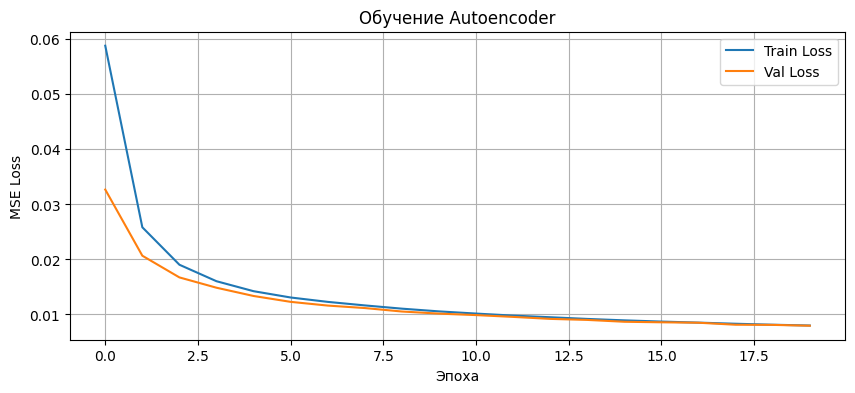

In [7]:
# График обучения
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.title('Обучение Autoencoder')
plt.legend()
plt.grid(True)
plt.show()

## 2. Визуализация результатов

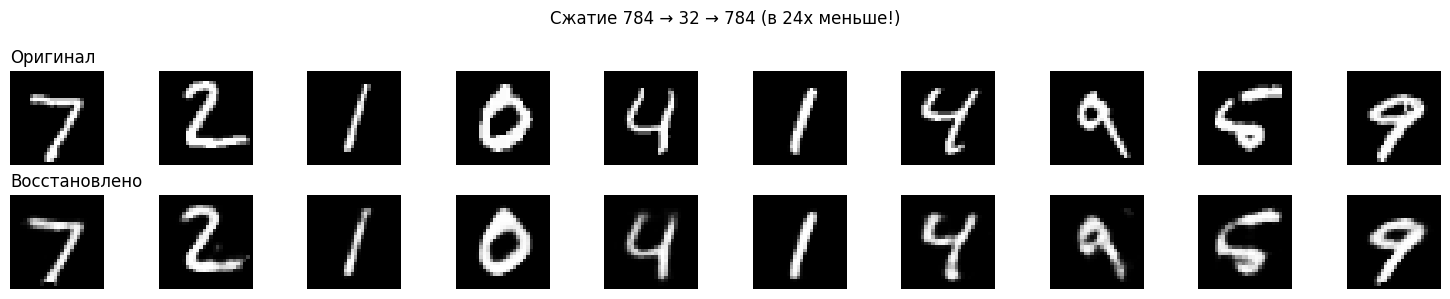

In [8]:
# Реконструкция тестовых изображений
reconstructed = autoencoder.predict(x_test_flat[:10], verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    # Оригинал
    axes[0, i].imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Оригинал', loc='left')
    
    # Реконструкция
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Восстановлено', loc='left')

plt.suptitle(f'Сжатие 784 → {LATENT_DIM} → 784 (в {784//LATENT_DIM}x меньше!)')
plt.tight_layout()
plt.show()

## 3. Латентное пространство

In [9]:
# Кодируем все тестовые данные
encoded_imgs = encoder.predict(x_test_flat, verbose=0)
print(f'Форма закодированных данных: {encoded_imgs.shape}')
print(f'Каждое изображение представлено {LATENT_DIM} числами')

Форма закодированных данных: (10000, 32)
Каждое изображение представлено 32 числами


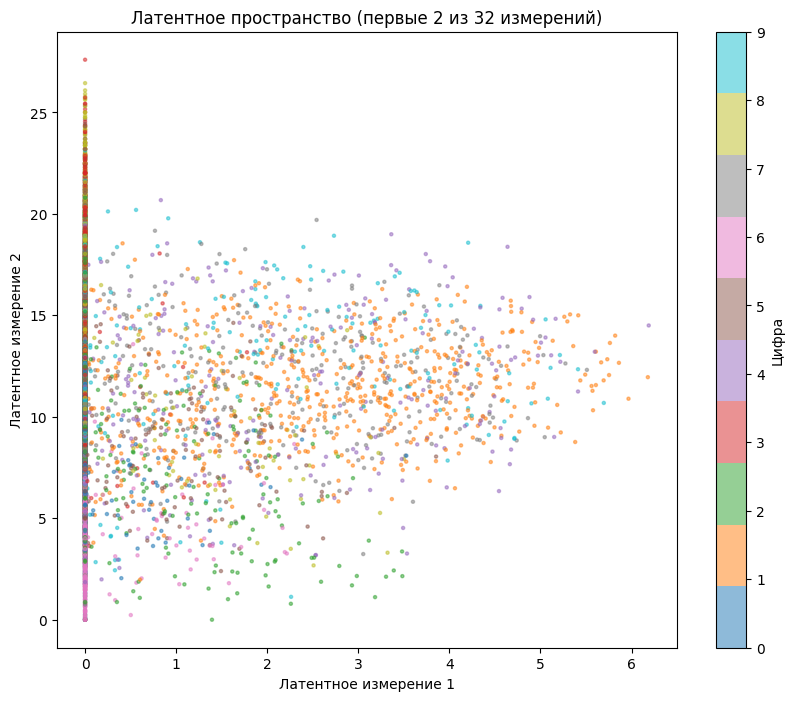

Похожие цифры группируются вместе!


In [10]:
# Визуализация латентного пространства (первые 2 измерения)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(encoded_imgs[:, 0], encoded_imgs[:, 1], 
                      c=y_test, cmap='tab10', alpha=0.5, s=5)
plt.colorbar(scatter, label='Цифра')
plt.xlabel('Латентное измерение 1')
plt.ylabel('Латентное измерение 2')
plt.title('Латентное пространство (первые 2 из 32 измерений)')
plt.show()

print('Похожие цифры группируются вместе!')

---
# Часть 2: Convolutional Autoencoder (лучше для изображений)

In [11]:
# Данные для свёрточного автоэнкодера
x_train_conv = x_train.reshape(-1, 28, 28, 1)
x_test_conv = x_test.reshape(-1, 28, 28, 1)

print('Форма для CNN:', x_train_conv.shape)

Форма для CNN: (60000, 28, 28, 1)


In [12]:
# Convolutional Autoencoder (улучшенный)
conv_autoencoder = keras.Sequential([
    # Encoder
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),  # 28→14
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),  # 14→7
    
    # Bottleneck: 7x7x64
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    
    # Decoder
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),  # 7→14
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),  # 14→28
    layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
], name='conv_autoencoder')

conv_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
conv_autoencoder.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,529 (291.13 KB)

 Trainable params: 74,529 (291.13 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Обучение Conv Autoencoder
conv_history = conv_autoencoder.fit(
    x_train_conv, x_train_conv,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_conv, x_test_conv),
    verbose=1
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - loss: 0.1566 - val_loss: 0.0833
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - loss: 0.0791 - val_loss: 0.0752
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - loss: 0.0741 - val_loss: 0.0719
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - loss: 0.0717 - val_loss: 0.0705
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - loss: 0.0702 - val_loss: 0.0693
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - loss: 0.0694 - val_loss: 0.0683
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 0.0686 - val_loss: 0.0677
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - loss: 0.0681 - val_loss: 0.0679
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 0.0676 - val_loss: 0.0668
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - loss: 0.0673 - val_loss: 0.0666


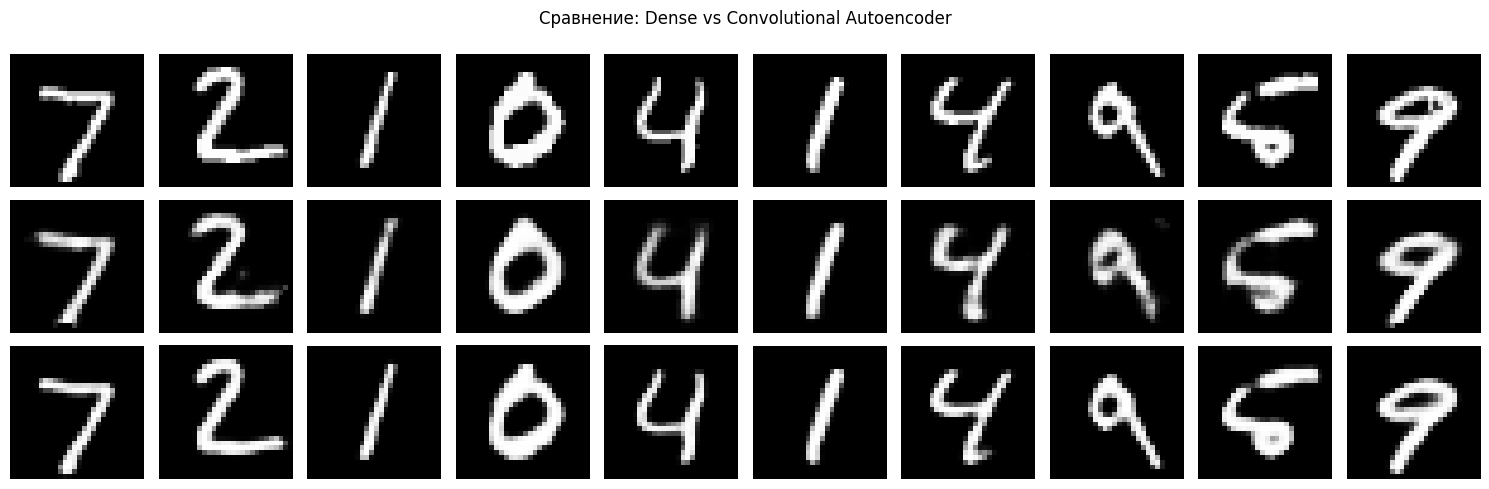

Conv Autoencoder лучше сохраняет детали!


In [14]:
# Сравнение Dense vs Conv Autoencoder
conv_reconstructed = conv_autoencoder.predict(x_test_conv[:10], verbose=0)

fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    # Оригинал
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].axis('off')
    
    # Dense Autoencoder
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    
    # Conv Autoencoder
    axes[2, i].imshow(conv_reconstructed[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Оригинал')
axes[1, 0].set_ylabel('Dense AE')
axes[2, 0].set_ylabel('Conv AE')

plt.suptitle('Сравнение: Dense vs Convolutional Autoencoder')
plt.tight_layout()
plt.show()

print('Conv Autoencoder лучше сохраняет детали!')

---
# Часть 3: Denoising Autoencoder (удаление шума)

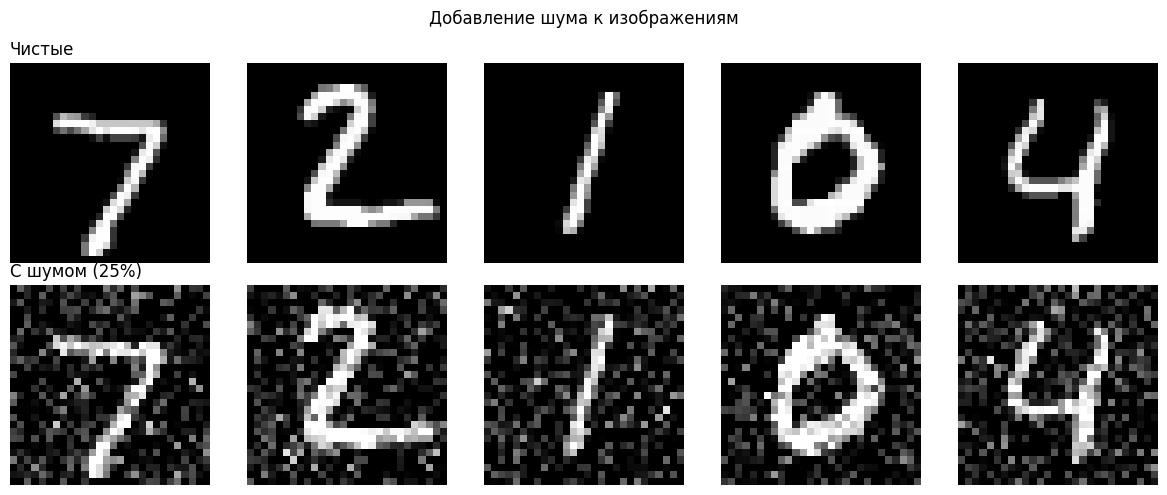

In [15]:
# Добавляем шум к изображениям
noise_factor = 0.25  # уменьшили с 0.5 до 0.25

x_train_noisy = x_train_conv + noise_factor * np.random.normal(size=x_train_conv.shape)
x_test_noisy = x_test_conv + noise_factor * np.random.normal(size=x_test_conv.shape)

# Ограничиваем значения [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.).astype('float32')
x_test_noisy = np.clip(x_test_noisy, 0., 1.).astype('float32')

# Показываем примеры
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(x_test_conv[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Чистые', loc='left')
axes[1, 0].set_title('С шумом (25%)', loc='left')
plt.suptitle('Добавление шума к изображениям')
plt.tight_layout()
plt.show()

In [16]:
# Denoising Autoencoder (улучшенная архитектура)
denoising_ae = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    
    # Encoder
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Bottleneck
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    
    # Decoder
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
], name='denoising_autoencoder')

denoising_ae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy')

# Обучение: вход — шумные, выход — чистые!
print('Обучение Denoising Autoencoder...')
denoising_ae.fit(
    x_train_noisy, x_train_conv,  # шумные → чистые
    epochs=15,
    batch_size=128,
    validation_data=(x_test_noisy, x_test_conv),
    verbose=1
)

Обучение Denoising Autoencoder...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - loss: 0.1197 - val_loss: 0.0833
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - loss: 0.0813 - val_loss: 0.0789
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - loss: 0.0784 - val_loss: 0.0768
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - loss: 0.0769 - val_loss: 0.0758
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - loss: 0.0761 - val_loss: 0.0752
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 0.0755 - val_loss: 0.0746
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 0.0750 - val_loss: 0.0747
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - loss: 0.0746 - val_loss: 0.0739
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - loss: 0.0743 - val_loss: 0.0736
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - loss: 0.0740 - val_loss: 0.0734
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - loss: 0.0738 - val_loss: 0.0

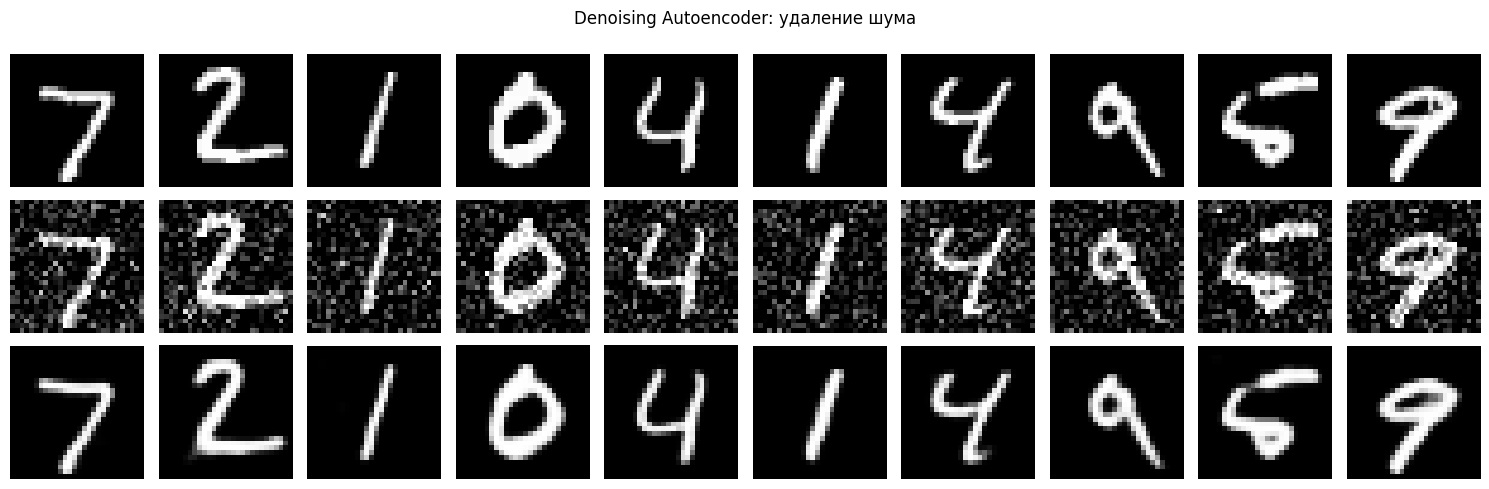

Autoencoder научился удалять шум!


In [17]:
# Результаты удаления шума
denoised = denoising_ae.predict(x_test_noisy[:10], verbose=0)

fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    axes[0, i].imshow(x_test_conv[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    
    axes[2, i].imshow(denoised[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Оригинал')
axes[1, 0].set_ylabel('С шумом')
axes[2, 0].set_ylabel('Очищено')

plt.suptitle('Denoising Autoencoder: удаление шума')
plt.tight_layout()
plt.show()

print('Autoencoder научился удалять шум!')

---
# Часть 4: Генерация новых изображений

In [18]:
# Можно генерировать новые изображения, 
# подавая случайные векторы в decoder

# Но сначала посмотрим распределение латентного пространства
print('Статистика латентного пространства:')
print(f'  Mean: {encoded_imgs.mean():.3f}')
print(f'  Std:  {encoded_imgs.std():.3f}')
print(f'  Min:  {encoded_imgs.min():.3f}')
print(f'  Max:  {encoded_imgs.max():.3f}')

Статистика латентного пространства:
  Mean: 8.047
  Std:  5.768
  Min:  0.000
  Max:  39.154


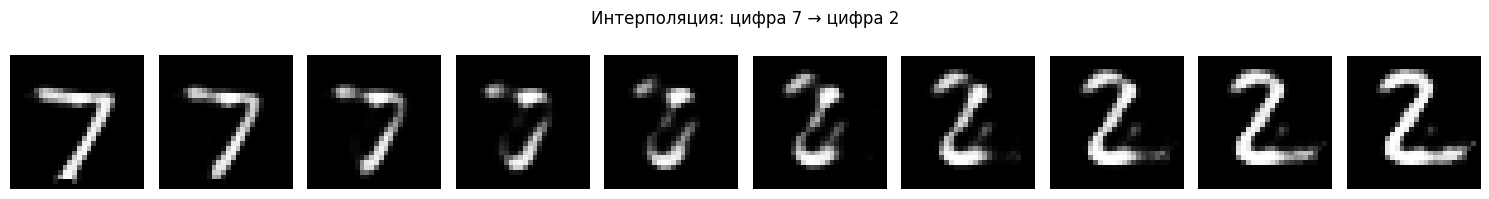

In [19]:
# Генерация через интерполяцию между реальными изображениями
# Берём две цифры и плавно переходим

idx1, idx2 = 0, 1  # индексы двух изображений
z1 = encoder.predict(x_test_flat[idx1:idx1+1], verbose=0)
z2 = encoder.predict(x_test_flat[idx2:idx2+1], verbose=0)

# Интерполяция
steps = 10
interpolated = []
for alpha in np.linspace(0, 1, steps):
    z = z1 * (1 - alpha) + z2 * alpha
    img = decoder.predict(z, verbose=0)
    interpolated.append(img.reshape(28, 28))

fig, axes = plt.subplots(1, steps, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(interpolated[i], cmap='gray')
    ax.axis('off')
plt.suptitle(f'Интерполяция: цифра {y_test[idx1]} → цифра {y_test[idx2]}')
plt.tight_layout()
plt.show()

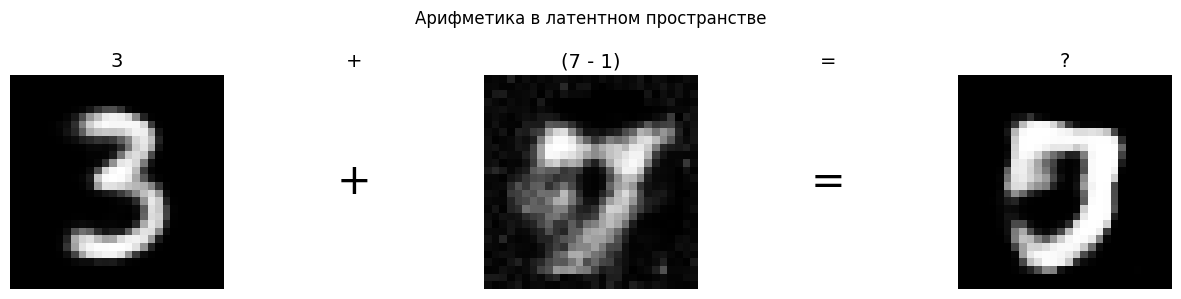

In [20]:
# Арифметика в латентном пространстве
# Находим средние представления для каждой цифры

digit_means = {}
for digit in range(10):
    mask = y_test == digit
    digit_means[digit] = encoded_imgs[mask].mean(axis=0)

# Эксперимент: 3 + (7 - 1) = ?
z_result = digit_means[3] + (digit_means[7] - digit_means[1])
result_img = decoder.predict(z_result.reshape(1, -1), verbose=0)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
titles = ['3', '+', '(7 - 1)', '=', '?']
images = [
    decoder.predict(digit_means[3].reshape(1, -1), verbose=0),
    None,
    decoder.predict((digit_means[7] - digit_means[1]).reshape(1, -1), verbose=0),
    None,
    result_img
]

for i, ax in enumerate(axes):
    if images[i] is not None:
        ax.imshow(images[i].reshape(28, 28), cmap='gray')
    else:
        ax.text(0.5, 0.5, titles[i], fontsize=30, ha='center', va='center')
    ax.axis('off')
    ax.set_title(titles[i], fontsize=14)

plt.suptitle('Арифметика в латентном пространстве')
plt.tight_layout()
plt.show()

## Итог

```
┌─────────────────────────────────────────────────────────────────┐
│                      Autoencoder                                │
├─────────────────────────────────────────────────────────────────┤
│  Encoder          — сжимает данные в латентное представление    │
│  Decoder          — восстанавливает данные из латентного        │
│  Bottleneck       — узкое место, заставляет учить важное        │
├─────────────────────────────────────────────────────────────────┤
│  Применения:                                                    │
│  • Сжатие данных                                                │
│  • Удаление шума (Denoising)                                    │
│  • Обнаружение аномалий                                         │
│  • Извлечение признаков                                         │
│  • Предобучение для других задач                                │
├─────────────────────────────────────────────────────────────────┤
│  Ограничения:                                                   │
│  • Генерация новых данных хуже чем GAN/VAE                      │
│  • Латентное пространство не непрерывно                         │
└─────────────────────────────────────────────────────────────────┘

Следующий шаг: VAE (Variational Autoencoder) — лучше для генерации
```